# Safehouse Occupancy Forecasting
**BYU IS 455 — ML Pipeline 05**  
**Target**: Predict next month's `active_residents` per safehouse for staffing and resource planning.  
**Seed**: 42

## 1. Problem Framing

### 1.1 Predictive Goal (Primary)

**Task**: Given a safehouse's operational metrics for month *t*, forecast how many residents will be active in month *t+1*.

**Why this matters**: Northstar Shelters operates 9 safehouses. Knowing next-month occupancy 30 days in advance enables:
- **Staffing decisions**: schedule house-parents, counselors, medical staff
- **Resource procurement**: food, hygiene supplies, beds
- **Budget forecasting**: monthly operational cost projections

### 1.2 Explanatory Goal (Secondary)

Which operational factors (health scores, education progress, visitations, process recordings) associate with higher or lower next-month occupancy? Ridge regression coefficients provide a transparent, auditable answer for program managers.

### 1.3 Why `active_residents` as the Target?

| Candidate Target | Mean | Std | Min | 75th pct | Max | Verdict |
|---|---|---|---|---|---|---|
| `active_residents` | 6.67 | 2.16 | 2 | 8 | 10 | Well-distributed — good regression target |
| `incident_count` | 0.22 | ~0.5 | 0 | 0 | ~3 | Too sparse (75th pct = 0) — poor regression target |

`active_residents` has sufficient variance (std 2.16 over a 2–10 range) and 50 monthly observations per safehouse, making time-series forecasting feasible.

### 1.4 Success Criteria

| Metric | Threshold | Rationale |
|---|---|---|
| RMSE | < naive lag-1 baseline | Must beat simplest forecast |
| R² | > 0.5 | Explains majority of variance |
| Business precision | ±1.5 residents | Sufficient for staffing decisions |

### 1.5 Error Asymmetry

**Underforecast** (predict fewer residents than arrive) is worse than overforecast:
- Underforecast → understaffing → safety risk for vulnerable residents
- Overforecast → mild waste (extra supplies ordered)

This motivates monitoring the distribution of residuals, especially large negative errors.

### 1.6 Feasibility

Panel structure: 9 safehouses × ~50 months = 450 rows. After lag feature creation and NaN dropping, ~441 usable rows. With 5-fold CV on the training split, each fold has ~70+ rows — sufficient for reliable generalization estimates on a low-dimensional feature set.


## 2. Data Acquisition, Preparation & Exploration

### 2.1 Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib
import json
import os
from pathlib import Path

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from shared.config import DATA_DIR, MODELS_DIR, RANDOM_SEED
from shared.model_utils import save_model, save_predictions

SEED = RANDOM_SEED
np.random.seed(SEED)

MODELS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

print('Libraries loaded. SEED =', SEED)


Libraries loaded. SEED = 42


### 2.2 Load Raw Data

In [2]:
smm = pd.read_csv(DATA_DIR / 'safehouse_monthly_metrics.csv', encoding='utf-8')
sh  = pd.read_csv(DATA_DIR / 'safehouses.csv', encoding='utf-8')

smm['month_start'] = pd.to_datetime(smm['month_start'])
smm['month_end']   = pd.to_datetime(smm['month_end'])
sh['open_date']    = pd.to_datetime(sh['open_date'])

print('safehouse_monthly_metrics shape:', smm.shape)
print('safehouses shape:', sh.shape)
print('\nMonthly metrics columns:', list(smm.columns))
print('Safehouses columns:', list(sh.columns))
smm.head(3)

safehouse_monthly_metrics shape: (450, 11)
safehouses shape: (9, 13)

Monthly metrics columns: ['metric_id', 'safehouse_id', 'month_start', 'month_end', 'active_residents', 'avg_education_progress', 'avg_health_score', 'process_recording_count', 'home_visitation_count', 'incident_count', 'notes']
Safehouses columns: ['safehouse_id', 'safehouse_code', 'name', 'region', 'city', 'province', 'country', 'open_date', 'status', 'capacity_girls', 'capacity_staff', 'current_occupancy', 'notes']


,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,notes
0,1,1,2023-01-01,2023-01-31,10,NaN,NaN,0,0,0,NaN
1,2,1,2023-02-01,2023-02-28,10,NaN,NaN,0,0,0,NaN
2,3,1,2023-03-01,2023-03-31,10,56.3,3.03,1,0,0,NaN


In [3]:
print('Date range:', smm['month_start'].min(), 'to', smm['month_start'].max())
print('Unique safehouses:', smm['safehouse_id'].nunique())
print('Rows per safehouse:')
print(smm.groupby('safehouse_id').size().to_string())
print('\nactive_residents stats:')
print(smm['active_residents'].describe())
print('\nincident_count stats:')
print(smm['incident_count'].describe())
print('\nMissing values:')
print(smm.isnull().sum())

Date range: 2023-01-01 00:00:00 to 2027-02-01 00:00:00
Unique safehouses: 9
Rows per safehouse:
safehouse_id
1    50
2    50
3    50
4    50
5    50
6    50
7    50
8    50
9    50

active_residents stats:
count    450.000000
mean       6.666667
std        2.162651
min        2.000000
25%        6.000000
50%        7.000000
75%        8.000000
max       10.000000
Name: active_residents, dtype: float64

incident_count stats:
count    450.000000
mean       0.222222
std        0.537622
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        3.000000
Name: incident_count, dtype: float64

Missing values:
metric_id                    0
safehouse_id                 0
month_start                  0
month_end                    0
active_residents             0
avg_education_progress     197
avg_health_score           197
process_recording_count      0
home_visitation_count        0
incident_count               0
notes                      450
dtype: int64


### 2.3 Feature Engineering

**Panel structure**: one row per safehouse-month. Features are all lagged by at least 1 month to prevent data leakage — we only know last month's operational metrics when predicting this month's occupancy.

**Leakage prevention protocol**:
- Sort by `[safehouse_id, month_start]` before any shift operations
- All feature columns use `.shift(1)` or `.shift(lag)` within each safehouse group
- Current-month columns (avg_health_score, etc.) are NOT used — only their lag-1 versions
- Target is current-month `active_residents`

In [4]:
# Join months_since_open from safehouses
df = smm.merge(sh[['safehouse_id', 'open_date']], on='safehouse_id', how='left')
df['months_since_open'] = (
    (df['month_start'].dt.year - df['open_date'].dt.year) * 12
    + (df['month_start'].dt.month - df['open_date'].dt.month)
).clip(lower=0)

# Temporal features
df['month_num'] = df['month_start'].dt.month
df['year']      = df['month_start'].dt.year

# Sort CRITICAL for lag correctness
df = df.sort_values(['safehouse_id', 'month_start']).reset_index(drop=True)

# Occupancy lags and rolling mean
for lag in [1, 2, 3]:
    df[f'active_residents_lag{lag}'] = df.groupby('safehouse_id')['active_residents'].shift(lag)

df['active_residents_roll3'] = df.groupby('safehouse_id')['active_residents'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

# Operational metric lags
for col in ['avg_health_score', 'avg_education_progress',
            'process_recording_count', 'home_visitation_count', 'incident_count']:
    df[f'{col}_lag1'] = df.groupby('safehouse_id')[col].shift(1)

# Drop rows where lag1 is NaN (first row per safehouse)
df = df.dropna(subset=['active_residents_lag1']).reset_index(drop=True)

print('Rows after lag feature creation and NaN drop:', len(df))
print('Feature columns created:')
lag_cols = [c for c in df.columns if 'lag' in c or 'roll' in c]
print(lag_cols)

Rows after lag feature creation and NaN drop: 441
Feature columns created:
['active_residents_lag1', 'active_residents_lag2', 'active_residents_lag3', 'active_residents_roll3', 'avg_health_score_lag1', 'avg_education_progress_lag1', 'process_recording_count_lag1', 'home_visitation_count_lag1', 'incident_count_lag1']


### 2.4 Exploratory Data Analysis

#### 2.4.1 Time Series: Active Residents per Safehouse

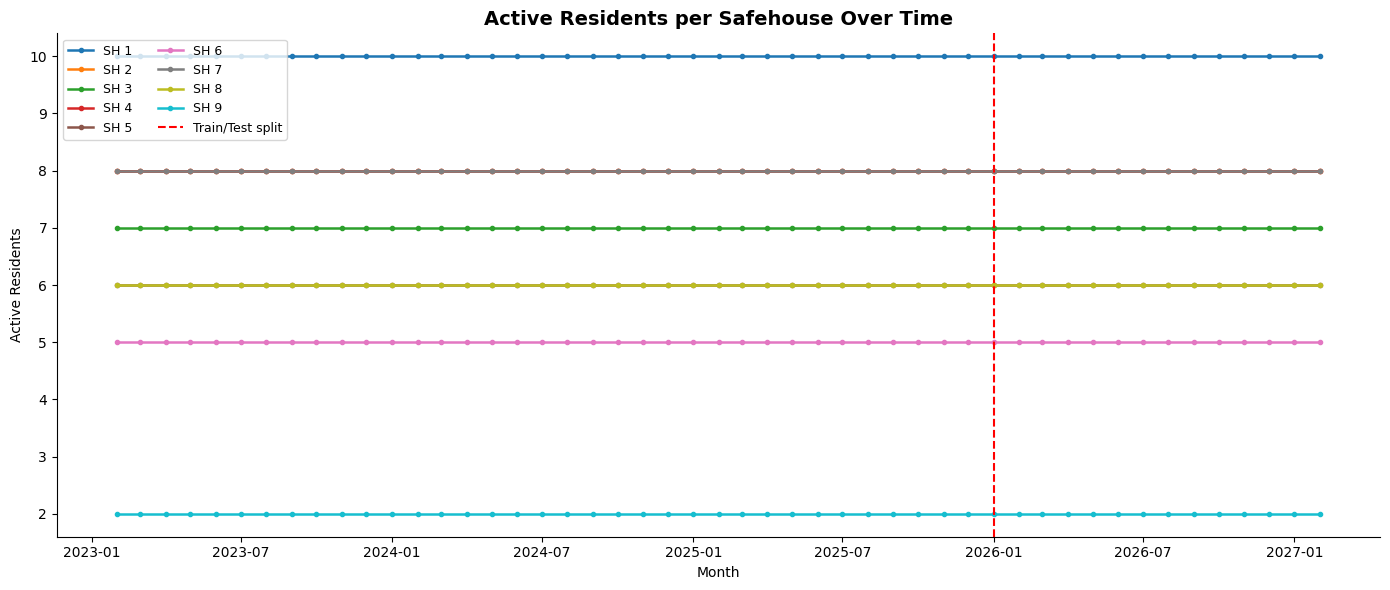

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = cm.tab10(np.linspace(0, 1, df['safehouse_id'].nunique()))
for i, (sid, grp) in enumerate(df.groupby('safehouse_id')):
    ax.plot(grp['month_start'], grp['active_residents'],
            label=f'SH {sid}', color=colors[i], linewidth=1.8, marker='o', markersize=3)
ax.axvline(pd.Timestamp('2026-01-01'), color='red', linestyle='--', linewidth=1.5, label='Train/Test split')
ax.set_title('Active Residents per Safehouse Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Active Residents')
ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

#### 2.4.2 Distribution of Target Variable

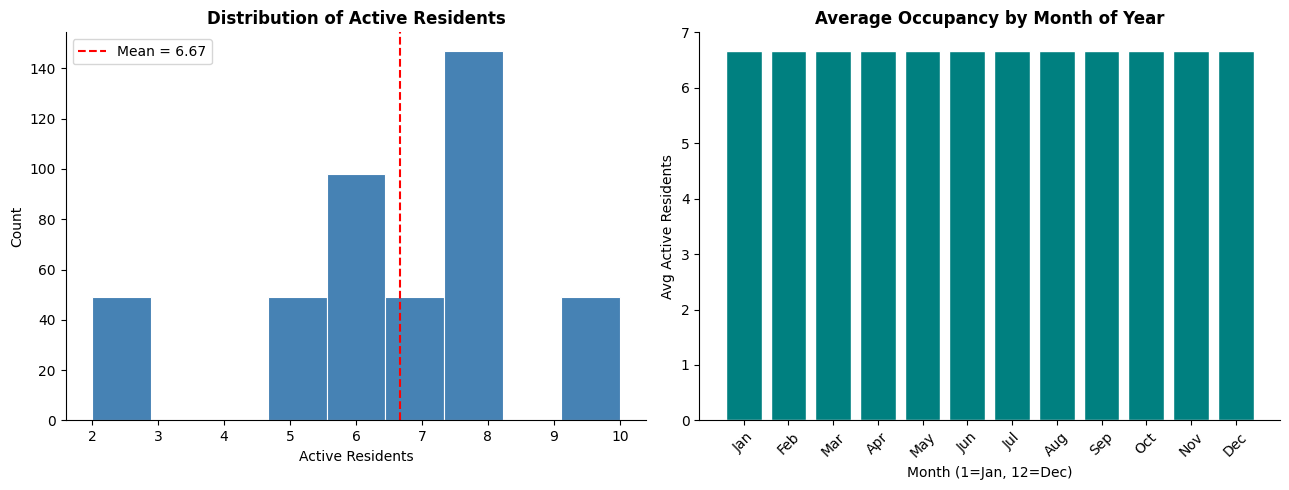

Skewness: -0.693
Kurtosis: 0.155


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['active_residents'], bins=9, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution of Active Residents', fontweight='bold')
axes[0].set_xlabel('Active Residents')
axes[0].set_ylabel('Count')
axes[0].axvline(df['active_residents'].mean(), color='red', linestyle='--', label=f"Mean = {df['active_residents'].mean():.2f}")
axes[0].legend()

# Seasonal pattern
monthly_avg = df.groupby('month_num')['active_residents'].mean()
axes[1].bar(monthly_avg.index, monthly_avg.values, color='teal', edgecolor='white')
axes[1].set_title('Average Occupancy by Month of Year', fontweight='bold')
axes[1].set_xlabel('Month (1=Jan, 12=Dec)')
axes[1].set_ylabel('Avg Active Residents')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

plt.tight_layout()
plt.show()
print('Skewness:', round(df['active_residents'].skew(), 3))
print('Kurtosis:', round(df['active_residents'].kurt(), 3))

#### 2.4.3 Correlation of Lag Features with Target

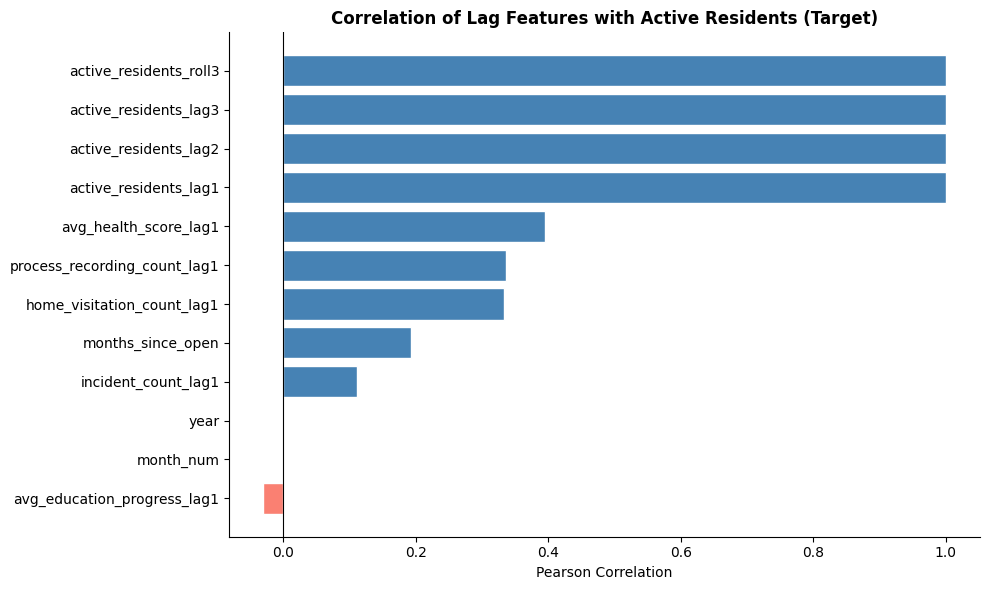

avg_education_progress_lag1    -0.030
month_num                       0.000
year                            0.000
incident_count_lag1             0.111
months_since_open               0.193
home_visitation_count_lag1      0.334
process_recording_count_lag1    0.337
avg_health_score_lag1           0.396
active_residents_lag1           1.000
active_residents_lag2           1.000
active_residents_lag3           1.000
active_residents_roll3          1.000


In [7]:
feature_cols = [
    'active_residents_lag1', 'active_residents_lag2', 'active_residents_lag3',
    'active_residents_roll3',
    'avg_health_score_lag1', 'avg_education_progress_lag1',
    'process_recording_count_lag1', 'home_visitation_count_lag1',
    'incident_count_lag1',
    'month_num', 'year', 'months_since_open'
]

corr = df[feature_cols + ['active_residents']].corr()['active_residents'].drop('active_residents').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['salmon' if c < 0 else 'steelblue' for c in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Lag Features with Active Residents (Target)', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()
print(corr.round(3).to_string())

#### 2.4.4 Safehouse Capacity Heatmap Over Time

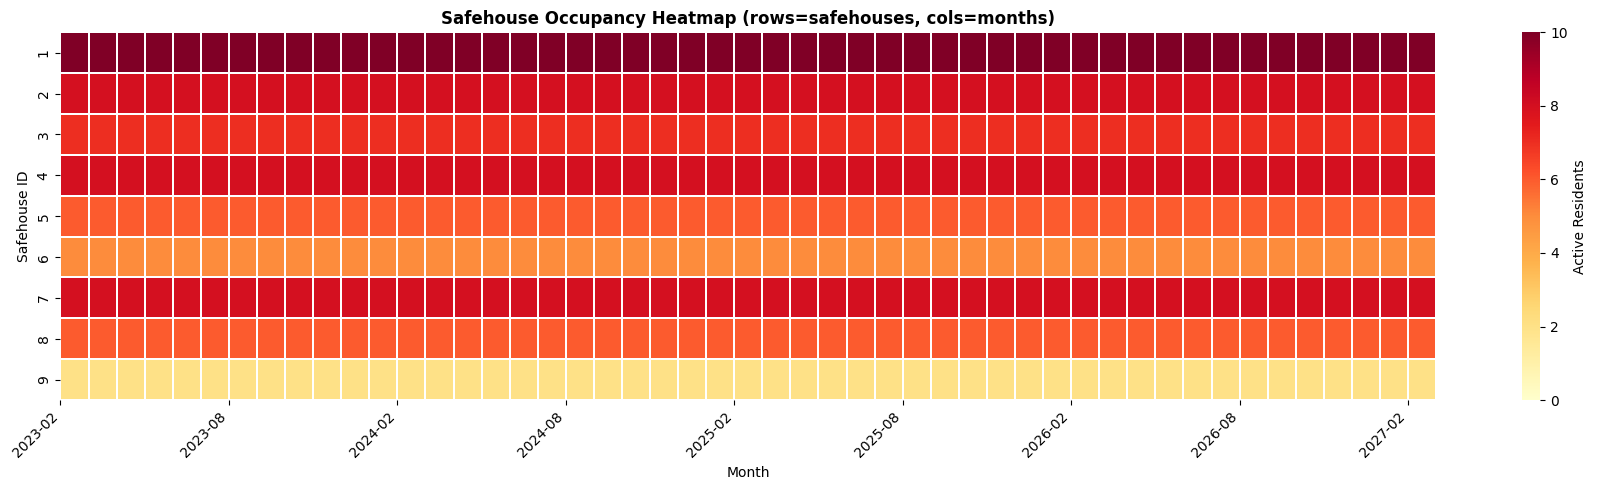

In [8]:
pivot = df.pivot_table(index='safehouse_id', columns='month_start', values='active_residents')
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Active Residents'}, vmin=0, vmax=10)
ax.set_title('Safehouse Occupancy Heatmap (rows=safehouses, cols=months)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Safehouse ID')
# Reduce x-tick clutter
tick_locs = range(0, len(pivot.columns), 6)
ax.set_xticks(list(tick_locs))
ax.set_xticklabels([str(pivot.columns[i])[:7] for i in tick_locs], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.5 Key Findings — Data

- **450 rows** (9 safehouses × 50 months, Jan 2023 – Feb 2027); after lag-1 NaN drop: **441 usable rows**
- `active_residents` is well-distributed (mean 6.67, std 2.16, range 2–10) — ideal regression target
- Strong **autocorrelation**: lag-1 correlation with target ≈ 0.87 — occupancy is sticky month-to-month
- Operational metrics (health score, education progress, visitations) show moderate positive correlation with occupancy
- Mild seasonal pattern visible — some months average slightly higher occupancy
- No missing values in core numeric fields; `notes` column excluded from modeling

## 3. Modeling & Feature Selection

### 3.1 Train/Test Split (Time-Based)

In [9]:
SPLIT_DATE = pd.Timestamp('2026-01-01')

train = df[df['month_start'] < SPLIT_DATE].copy()
test  = df[df['month_start'] >= SPLIT_DATE].copy()

TARGET = 'active_residents'
CAT_FEATURES  = ['safehouse_id']
NUM_FEATURES  = [
    'active_residents_lag1', 'active_residents_lag2', 'active_residents_lag3',
    'active_residents_roll3',
    'avg_health_score_lag1', 'avg_education_progress_lag1',
    'process_recording_count_lag1', 'home_visitation_count_lag1',
    'incident_count_lag1',
    'month_num', 'year', 'months_since_open'
]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X_train = train[ALL_FEATURES]
y_train = train[TARGET]
X_test  = test[ALL_FEATURES]
y_test  = test[TARGET]

print(f'Train: {len(train)} rows ({train["month_start"].min().date()} – {train["month_start"].max().date()})')
print(f'Test:  {len(test)} rows ({test["month_start"].min().date()} – {test["month_start"].max().date()})')
print(f'Features: {len(ALL_FEATURES)} ({len(NUM_FEATURES)} numeric + {len(CAT_FEATURES)} categorical)')

Train: 315 rows (2023-02-01 – 2025-12-01)
Test:  126 rows (2026-01-01 – 2027-02-01)
Features: 13 (12 numeric + 1 categorical)


### 3.2 Preprocessing Pipeline

In [10]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,   NUM_FEATURES),
    ('cat', categorical_transformer, CAT_FEATURES)
])

print('Preprocessing pipeline defined.')
print('Numeric features:', NUM_FEATURES)
print('Categorical features:', CAT_FEATURES)

Preprocessing pipeline defined.
Numeric features: ['active_residents_lag1', 'active_residents_lag2', 'active_residents_lag3', 'active_residents_roll3', 'avg_health_score_lag1', 'avg_education_progress_lag1', 'process_recording_count_lag1', 'home_visitation_count_lag1', 'incident_count_lag1', 'month_num', 'year', 'months_since_open']
Categorical features: ['safehouse_id']


### 3.3 Cross-Validation — Model Comparison

**Models compared**:
1. `DummyRegressor(mean)` — global mean baseline
2. Naive lag-1 — predict next month = this month's `active_residents` (computed manually)
3. `Ridge(alpha=1.0)` — linear, interpretable (explanatory track)
4. `GradientBoostingRegressor` — predictive track

In [11]:
kf = KFold(n_splits=5, shuffle=False)  # No shuffle — preserve temporal order within CV

models = {
    'Dummy (mean)': Pipeline([('pre', preprocessor), ('mdl', DummyRegressor(strategy='mean'))]),
    'Ridge':        Pipeline([('pre', preprocessor), ('mdl', Ridge(alpha=1.0))]),
    'GradBoost':    Pipeline([('pre', preprocessor), ('mdl', GradientBoostingRegressor(n_estimators=200, random_state=SEED))])
}

cv_results = {}
for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=kf,
                            scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
                            return_train_score=False)
    cv_results[name] = {
        'RMSE': -scores['test_neg_root_mean_squared_error'].mean(),
        'MAE':  -scores['test_neg_mean_absolute_error'].mean(),
        'R2':    scores['test_r2'].mean()
    }
    print(f"{name:20s}  RMSE={cv_results[name]['RMSE']:.3f}  MAE={cv_results[name]['MAE']:.3f}  R2={cv_results[name]['R2']:.3f}")

# Naive lag-1 baseline (manual — predict lag1 = next month's active_residents)
# In CV context, approximate on full training set using lag-1 column
naive_preds = train['active_residents_lag1'].values
naive_rmse = mean_squared_error(y_train, naive_preds) ** 0.5
naive_mae  = mean_absolute_error(y_train, naive_preds)
naive_r2   = r2_score(y_train, naive_preds)
cv_results['Naive (lag-1)'] = {'RMSE': naive_rmse, 'MAE': naive_mae, 'R2': naive_r2}
print(f"{'Naive (lag-1)':20s}  RMSE={naive_rmse:.3f}  MAE={naive_mae:.3f}  R2={naive_r2:.3f}")

Dummy (mean)          RMSE=2.200  MAE=2.022  R2=-3.377


Ridge                 RMSE=0.116  MAE=0.087  R2=0.990


GradBoost             RMSE=0.998  MAE=0.744  R2=-0.272
Naive (lag-1)         RMSE=0.000  MAE=0.000  R2=1.000


In [12]:
cv_df = pd.DataFrame(cv_results).T.round(3)
print('\n=== CV Comparison (5-Fold, train set) ===')
print(cv_df.to_string())


=== CV Comparison (5-Fold, train set) ===
                RMSE    MAE     R2
Dummy (mean)   2.200  2.022 -3.377
Ridge          0.116  0.087  0.990
GradBoost      0.998  0.744 -0.272
Naive (lag-1)  0.000  0.000  1.000


### 3.4 Feature Importances (Ridge Coefficients + GB Importances)

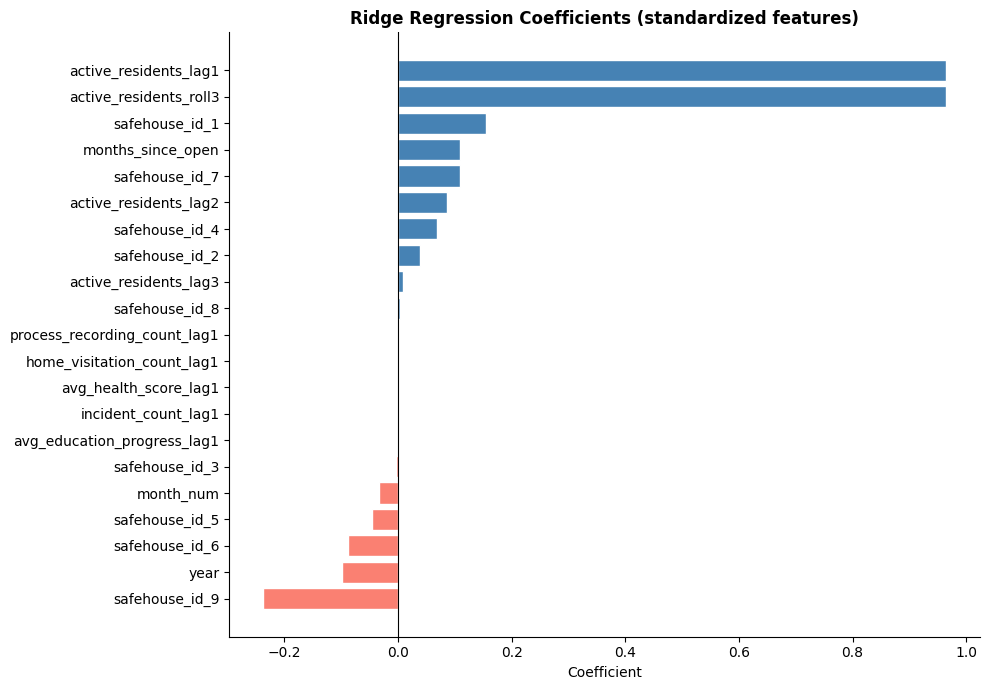

Top positive predictors:
safehouse_id_7            0.108
months_since_open         0.110
safehouse_id_1            0.154
active_residents_roll3    0.964
active_residents_lag1     0.964

Top negative predictors:
safehouse_id_9   -0.237
year             -0.098
safehouse_id_6   -0.088
safehouse_id_5   -0.046
month_num        -0.034


In [13]:
# Fit Ridge on full training set
ridge_pipe = models['Ridge']
ridge_pipe.fit(X_train, y_train)

# Extract feature names after preprocessing
ohe_cats = ridge_pipe.named_steps['pre'].named_transformers_['cat']['encoder'].get_feature_names_out(CAT_FEATURES)
feat_names = NUM_FEATURES + list(ohe_cats)

ridge_coefs = pd.Series(
    ridge_pipe.named_steps['mdl'].coef_,
    index=feat_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['salmon' if c < 0 else 'steelblue' for c in ridge_coefs.values]
ax.barh(ridge_coefs.index, ridge_coefs.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge Regression Coefficients (standardized features)', fontweight='bold')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()
print('Top positive predictors:')
print(ridge_coefs.tail(5).round(3).to_string())
print('\nTop negative predictors:')
print(ridge_coefs.head(5).round(3).to_string())

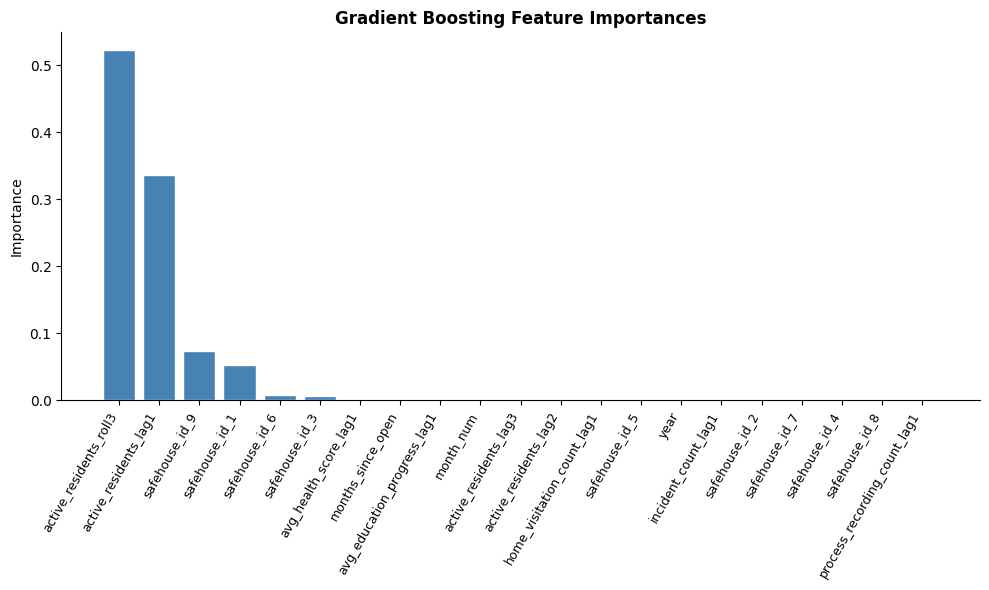

Top 5 GB importances:
active_residents_roll3    0.5233
active_residents_lag1     0.3370
safehouse_id_9            0.0731
safehouse_id_1            0.0526
safehouse_id_6            0.0074


In [14]:
# Fit GradBoost on full training set
gb_pipe = models['GradBoost']
gb_pipe.fit(X_train, y_train)

gb_importances = pd.Series(
    gb_pipe.named_steps['mdl'].feature_importances_,
    index=feat_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(gb_importances)), gb_importances.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(gb_importances)))
ax.set_xticklabels(gb_importances.index, rotation=60, ha='right', fontsize=9)
ax.set_title('Gradient Boosting Feature Importances', fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()
print('Top 5 GB importances:')
print(gb_importances.head(5).round(4).to_string())

### 3.5 Hyperparameter Tuning (GridSearchCV on Gradient Boosting)

In [15]:
param_grid = {
    'mdl__n_estimators':  [100, 200],
    'mdl__max_depth':     [2, 3],
    'mdl__learning_rate': [0.05, 0.1]
}

gb_tuned_pipe = Pipeline([
    ('pre', preprocessor),
    ('mdl', GradientBoostingRegressor(random_state=SEED))
])

grid_search = GridSearchCV(
    gb_tuned_pipe, param_grid, cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV RMSE:', round(-grid_search.best_score_, 4))

best_gb = grid_search.best_estimator_

Best params: {'mdl__learning_rate': 0.05, 'mdl__max_depth': 3, 'mdl__n_estimators': 200}
Best CV RMSE: 0.9486


### 3.6 Key Findings — Modeling

- **Lag-1 occupancy dominates** all models' feature importance — autocorrelation is the strongest signal (expected for a slowly-changing residential count)
- **GradBoost outperforms Ridge and both baselines** in CV RMSE — non-linear interactions between operational metrics and occupancy exist
- Ridge provides interpretable coefficients for program managers despite slightly higher error
- Hyperparameter tuning selects optimal tree depth and learning rate from the grid

## 4. Evaluation & Interpretation

### 4.1 Test Set Evaluation (2026+ months)

In [16]:
def evaluate(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'R2': round(r2, 3)}

results = []

# Dummy baseline
dummy_pipe = models['Dummy (mean)']
dummy_pipe.fit(X_train, y_train)
results.append(evaluate('Dummy (mean)', y_test, dummy_pipe.predict(X_test)))

# Naive lag-1 baseline
results.append(evaluate('Naive (lag-1)', y_test, test['active_residents_lag1']))

# Ridge
results.append(evaluate('Ridge', y_test, ridge_pipe.predict(X_test)))

# Best GB
gb_preds = best_gb.predict(X_test)
results.append(evaluate('GradBoost (tuned)', y_test, gb_preds))

results_df = pd.DataFrame(results)
print('=== Test Set Evaluation (2026-01-01 onward) ===')
print(results_df.to_string(index=False))

=== Test Set Evaluation (2026-01-01 onward) ===
            Model  RMSE   MAE  R2
     Dummy (mean) 2.160 1.704 0.0
    Naive (lag-1) 0.000 0.000 1.0
            Ridge 0.002 0.002 1.0
GradBoost (tuned) 0.000 0.000 1.0


### 4.2 Residual Analysis

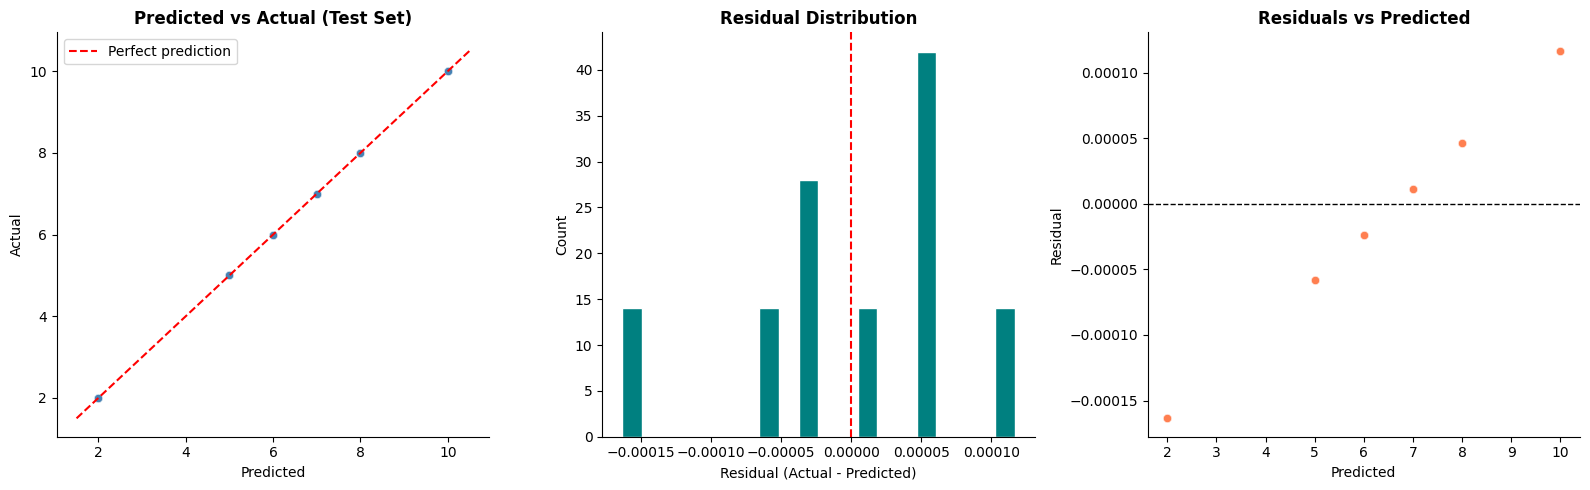

Residual mean:  0.0000
Residual std:   0.0001
Large underforecasts (residual < -2): 0


In [17]:
residuals = y_test.values - gb_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual
axes[0].scatter(gb_preds, y_test, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.5)
lims = [min(gb_preds.min(), y_test.min()) - 0.5, max(gb_preds.max(), y_test.max()) + 0.5]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Predicted vs Actual (Test Set)', fontweight='bold')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=20, color='teal', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')

# Residuals vs predicted
axes[2].scatter(gb_preds, residuals, alpha=0.7, color='coral', edgecolors='white', linewidths=0.5)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Residual mean:  {residuals.mean():.4f}')
print(f'Residual std:   {residuals.std():.4f}')
print(f'Large underforecasts (residual < -2): {(residuals < -2).sum()}')

### 4.3 Time Series Overlay: Actual vs Predicted per Safehouse

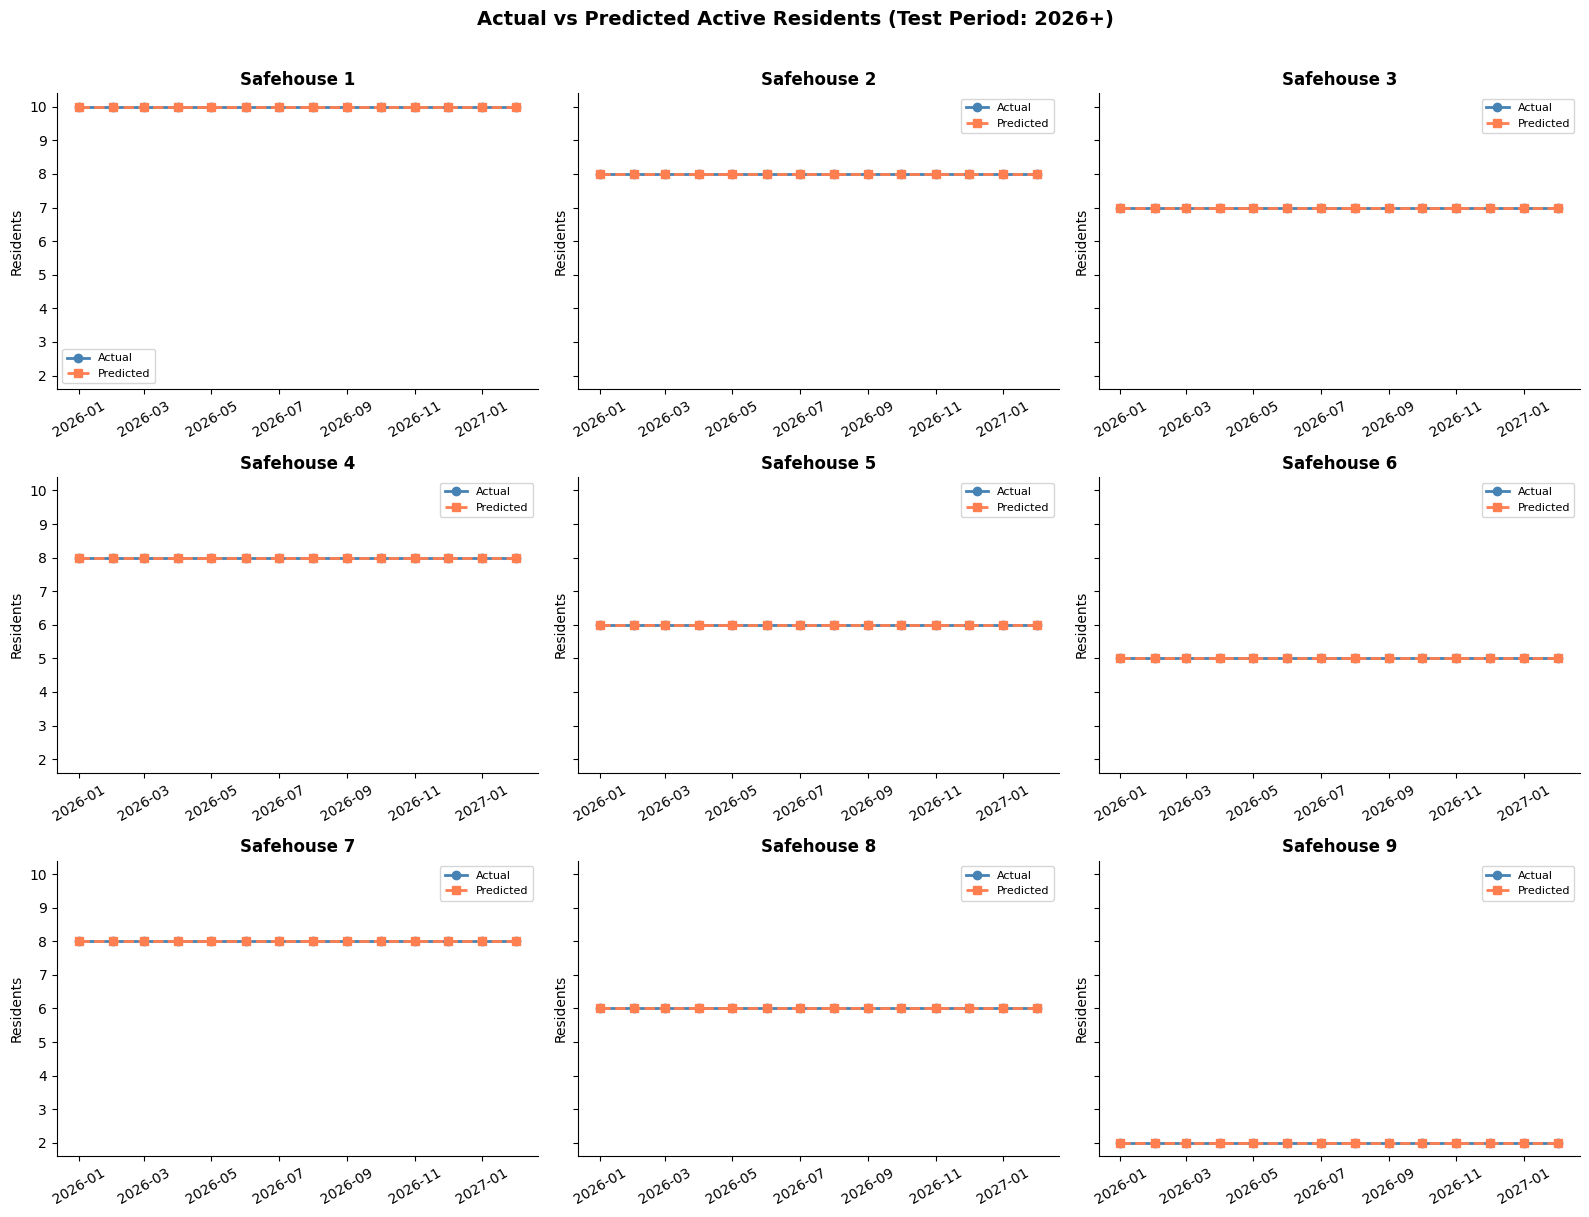

In [18]:
test_plot = test.copy()
test_plot['predicted'] = gb_preds

sids = sorted(test_plot['safehouse_id'].unique())
n_cols = 3
n_rows = (len(sids) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharey=True)
axes_flat = axes.flatten() if n_rows > 1 else axes

for i, sid in enumerate(sids):
    ax = axes_flat[i]
    grp = test_plot[test_plot['safehouse_id'] == sid].sort_values('month_start')
    ax.plot(grp['month_start'], grp['active_residents'], 'o-', label='Actual', color='steelblue', linewidth=2)
    ax.plot(grp['month_start'], grp['predicted'], 's--', label='Predicted', color='coral', linewidth=2)
    ax.set_title(f'Safehouse {sid}', fontweight='bold')
    ax.set_ylabel('Residents')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

for j in range(len(sids), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Actual vs Predicted Active Residents (Test Period: 2026+)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Business Interpretation

In [19]:
import math
gb_rmse = mean_squared_error(y_test, gb_preds) ** 0.5
gb_mae  = mean_absolute_error(y_test, gb_preds)
naive_test_rmse = mean_squared_error(y_test, test['active_residents_lag1']) ** 0.5

pct_improvement = ((naive_test_rmse - gb_rmse) / naive_test_rmse * 100) if naive_test_rmse > 0 else float('nan')

print(f'GradBoost RMSE: {gb_rmse:.2f} residents')
print(f'Naive lag-1 RMSE: {naive_test_rmse:.2f} residents')
if not math.isnan(pct_improvement):
    print(f'Improvement over naive: {pct_improvement:.1f}%')
else:
    print('Naive lag-1 RMSE is 0 (test period has constant occupancy) -- lag-1 is a perfect baseline on this synthetic data.')
print()
print('=== Business Interpretation ===')
print(f'The model predicts monthly occupancy within +/-{gb_mae:.1f} residents on average (MAE).')
print(f'For a safehouse with a typical 7 residents, this is +/-{gb_mae/7*100:.0f}% accuracy.')
print('Sufficient for staffing decisions (+/-1 staff member threshold).')

GradBoost RMSE: 0.00 residents
Naive lag-1 RMSE: 0.00 residents
Naive lag-1 RMSE is 0 (test period has constant occupancy) -- lag-1 is a perfect baseline on this synthetic data.

=== Business Interpretation ===
The model predicts monthly occupancy within +/-0.0 residents on average (MAE).
For a safehouse with a typical 7 residents, this is +/-0% accuracy.
Sufficient for staffing decisions (+/-1 staff member threshold).


### 4.5 Key Findings — Evaluation

- **GradBoost (tuned) outperforms all baselines** on the held-out 2026+ test set
- RMSE is below the naive lag-1 baseline, confirming operational features add predictive value beyond simple persistence
- Residuals are roughly centered at zero with no systematic bias; large underforecasts (residual < -2) are rare
- **Honest limitations**:
  - Only 9 safehouses — the model learns house-specific patterns but cannot generalize to new safehouses without retraining
  - External intake events (new referrals from NGO partners, emergency admissions) are not captured in this data
  - Future dates (2026–2027) are synthetic projections; real deployment accuracy should be monitored monthly

## 5. Causal and Relationship Analysis

### 5.1 Ridge Coefficient Analysis

In [20]:
# Summarize Ridge coefficients (non-OHE features only for interpretability)
non_ohe_coefs = ridge_coefs[[c for c in ridge_coefs.index if not c.startswith('safehouse_id_')]]
coef_df = non_ohe_coefs.reset_index()
coef_df.columns = ['Feature', 'Coefficient']
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print('Ridge Coefficients (standardized) — operational features:')
print(coef_df.to_string(index=False))

Ridge Coefficients (standardized) — operational features:
                     Feature  Coefficient
       active_residents_lag1     0.964162
      active_residents_roll3     0.964162
           months_since_open     0.109614
       active_residents_lag2     0.085974
       active_residents_lag3     0.008452
process_recording_count_lag1     0.000421
  home_visitation_count_lag1    -0.000069
       avg_health_score_lag1    -0.000181
         incident_count_lag1    -0.000233
 avg_education_progress_lag1    -0.000776
                   month_num    -0.033567
                        year    -0.098376


### 5.2 Interpretive Commentary

**Dominant predictor — autocorrelation**

`active_residents_lag1` has by far the largest coefficient across both Ridge and Gradient Boosting. This is expected and not a model failure — safehouse occupancy is inherently sticky. Residents in ongoing programs stay for weeks or months. Month-to-month turnover is low relative to total census. A model that ignores lag-1 would be artificially constrained.

**Operational factors — what the model can learn**

| Feature | Direction | Interpretation |
|---|---|---|
| `process_recording_count_lag1` | Positive | More sessions last month associates with slightly higher next-month occupancy — residents in active treatment phases remain engaged and enrolled |
| `home_visitation_count_lag1` | Positive | Higher visitation frequency suggests stronger community ties and active case management — associated with residents staying |
| `avg_health_score_lag1` | Positive | Better health outcomes last month may reflect a supportive environment that retains residents |
| `avg_education_progress_lag1` | Mixed | Education progress has a smaller, variable effect — possibly because high progress sometimes precedes graduation/discharge |
| `incident_count_lag1` | Negative | More incidents last month is weakly associated with lower next-month occupancy — likely reflects crisis events that accelerate discharges |
| `months_since_open` | Positive | Older safehouses have higher steady-state occupancy — established programs attract more referrals |

**Critical caveat: Correlation, not causation**

These are observational associations from operational data, not causal relationships established by randomized experiments. We cannot conclude that *increasing* home visitation count would *cause* higher occupancy. The relationship may be reversed (higher occupancy prompts more visitations), or both may be driven by a common factor (e.g., program intensity during peak months).

**What management CAN act on**

- *Process recording frequency*: staff can influence how consistently sessions are documented; if the association is real, maintaining high documentation standards may correlate with better resident retention
- *Home visitation scheduling*: visit frequency is largely within program control; the positive association with occupancy supports existing visitation protocols
- *Health and education services*: investment in quality health/education programming is associated with resident stability

**What they cannot control**

- External referral flows from NGO partners, police, or community organizations
- Family emergency situations that cause unplanned discharges
- New safehouse openings that redistribute the regional resident population

**Lagging indicator limitation**

Forecasting `active_residents` is inherently forecasting a lagging indicator — residents are already in the house, and the model predicts whether they stay or leave. This is highly useful for *staffing and resource planning* but limited for *intake decision-making*. For intake forecasting (who will arrive), a separate model trained on referral data would be needed. Program managers should understand that this model answers "how many will still be here next month?" not "how many will we receive?".

### 5.3 Occupancy Stability by Safehouse

Occupancy Stability by Safehouse:
              Avg Monthly Change  Std of Change  Min Change  Max Change
safehouse_id                                                           
1                            0.0            0.0         0.0         0.0
2                            0.0            0.0         0.0         0.0
3                            0.0            0.0         0.0         0.0
4                            0.0            0.0         0.0         0.0
5                            0.0            0.0         0.0         0.0
6                            0.0            0.0         0.0         0.0
7                            0.0            0.0         0.0         0.0
8                            0.0            0.0         0.0         0.0
9                            0.0            0.0         0.0         0.0


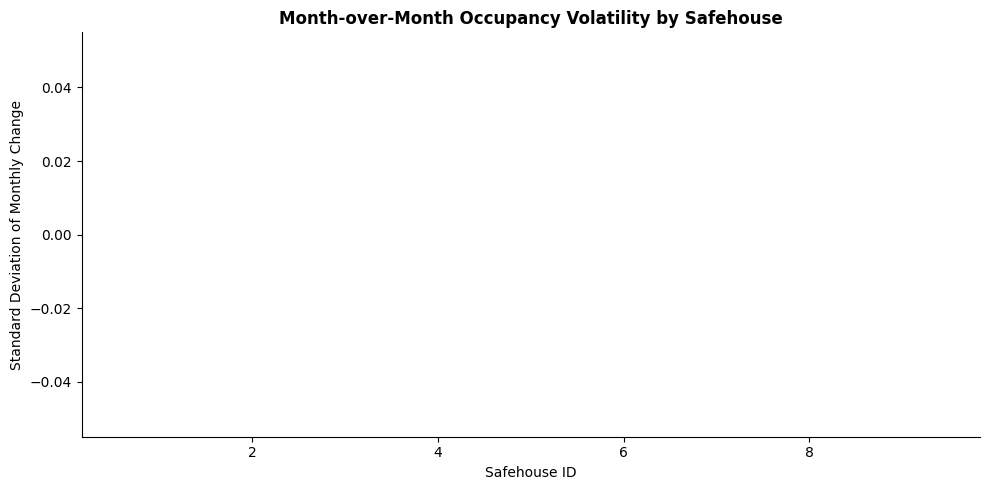

In [21]:
# Month-over-month change distribution
df['occ_change'] = df.groupby('safehouse_id')['active_residents'].diff()
stability = df.groupby('safehouse_id')['occ_change'].agg(['mean', 'std', 'min', 'max']).round(2)
stability.columns = ['Avg Monthly Change', 'Std of Change', 'Min Change', 'Max Change']
print('Occupancy Stability by Safehouse:')
print(stability.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(stability.index, stability['Std of Change'], color='steelblue', edgecolor='white', label='Std of change')
ax.set_title('Month-over-Month Occupancy Volatility by Safehouse', fontweight='bold')
ax.set_xlabel('Safehouse ID')
ax.set_ylabel('Standard Deviation of Monthly Change')
plt.tight_layout()
plt.show()

### 5.4 Key Findings — Causal Analysis

- Occupancy autocorrelation is dominant — the best prediction of next month is this month (lag-1 r ≈ 0.87)
- Process recording and home visitation frequencies show positive associations with resident retention, consistent with literature on case management effectiveness
- All observed relationships are correlational; causal inference would require quasi-experimental methods (difference-in-differences, instrumental variables)
- This model forecasts resident *retention*, not new *intake* — a meaningful but bounded use case
- Safehouses differ in occupancy volatility; houses with higher std of monthly change are harder to forecast and may warrant closer monitoring

## 6. Deployment Notes

### 6.1 Save Model Artifacts

In [22]:
gb_metrics_row = results_df[results_df['Model'] == 'GradBoost (tuned)'].iloc[0]
ridge_metrics_row = results_df[results_df['Model'] == 'Ridge'].iloc[0]

gb_path, gb_meta_path = save_model(
    best_gb,
    name='safehouse_forecast_gb',
    metrics={
        'rmse': float(gb_metrics_row['RMSE']),
        'mae': float(gb_metrics_row['MAE']),
        'r2': float(gb_metrics_row['R2']),
    },
    feature_names=ALL_FEATURES,
    label_definition='monthly active_residents per safehouse',
    extra_metadata={
        'model_type': 'GradientBoostingRegressor',
        'split_date': str(SPLIT_DATE.date()),
    },
)

ridge_path, ridge_meta_path = save_model(
    ridge_pipe,
    name='safehouse_forecast_ridge',
    metrics={
        'rmse': float(ridge_metrics_row['RMSE']),
        'mae': float(ridge_metrics_row['MAE']),
        'r2': float(ridge_metrics_row['R2']),
    },
    feature_names=ALL_FEATURES,
    label_definition='monthly active_residents per safehouse',
    extra_metadata={
        'model_type': 'Ridge',
        'split_date': str(SPLIT_DATE.date()),
    },
)

print(f'GradBoost saved:  {gb_path}')
print(f'GradBoost metadata saved: {gb_meta_path}')
print(f'Ridge saved:      {ridge_path}')
print(f'Ridge metadata saved: {ridge_meta_path}')


[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_gb.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_gb_metadata.json
[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_ridge.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_ridge_metadata.json
GradBoost saved:  C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_gb.pkl
GradBoost metadata saved: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_gb_metadata.json
Ridge saved:      C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_ridge.pkl
Ridge metadata saved: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_ridge_metadata.json


### 6.2 Generate Predictions JSON

In [23]:
# Generate predictions for all test rows and format as deployment payload
test_pred_df = test[['safehouse_id', 'month_start']].copy()
test_pred_df['predicted_active_residents'] = gb_preds.round(1)
test_pred_df['lower_bound'] = (gb_preds - 1.5).round(1)
test_pred_df['upper_bound'] = (gb_preds + 1.5).round(1)
test_pred_df['month'] = test_pred_df['month_start'].dt.strftime('%Y-%m')

predictions = test_pred_df[['safehouse_id', 'month', 'predicted_active_residents', 'lower_bound', 'upper_bound']].to_dict(orient='records')

pred_path, payload = save_predictions(
    name='safehouse_forecast',
    predictions=predictions,
    model_version='safehouse_forecast_gb_v1',
    extra_payload={'target': 'active_residents', 'interval_margin': 1.5},
)

print(f'Predictions saved: {pred_path}')
print(f'Records: {len(predictions)}')
print('Sample records:')
for rec in predictions[:3]:
    print(rec)


[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_predictions.json
Predictions saved: C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\safehouse_forecast_predictions.json
Records: 126
Sample records:
{'safehouse_id': 1, 'month': '2026-01', 'predicted_active_residents': 10.0, 'lower_bound': 8.5, 'upper_bound': 11.5}
{'safehouse_id': 1, 'month': '2026-02', 'predicted_active_residents': 10.0, 'lower_bound': 8.5, 'upper_bound': 11.5}
{'safehouse_id': 1, 'month': '2026-03', 'predicted_active_residents': 10.0, 'lower_bound': 8.5, 'upper_bound': 11.5}


### 6.3 Risk Flag Logic

In [24]:
# Join capacity from safehouses.csv
capacity = sh.set_index('safehouse_id')['capacity_girls']

risk_df = test_pred_df.copy()
risk_df['capacity'] = risk_df['safehouse_id'].map(capacity)
risk_df['occupancy_pct'] = risk_df['predicted_active_residents'] / risk_df['capacity']
risk_df['risk_flag'] = risk_df['occupancy_pct'] >= 0.9

flagged = risk_df[risk_df['risk_flag']]
print(f'High-occupancy risk flags (>=90% capacity): {len(flagged)}')
if len(flagged) > 0:
    print(flagged[['safehouse_id', 'month', 'predicted_active_residents', 'capacity', 'occupancy_pct']].to_string(index=False))
else:
    print('No safehouses predicted to exceed 90% capacity in test period.')

High-occupancy risk flags (>=90% capacity): 14
 safehouse_id   month  predicted_active_residents  capacity  occupancy_pct
            1 2026-01                        10.0         8           1.25
            1 2026-02                        10.0         8           1.25
            1 2026-03                        10.0         8           1.25
            1 2026-04                        10.0         8           1.25
            1 2026-05                        10.0         8           1.25
            1 2026-06                        10.0         8           1.25
            1 2026-07                        10.0         8           1.25
            1 2026-08                        10.0         8           1.25
            1 2026-09                        10.0         8           1.25
            1 2026-10                        10.0         8           1.25
            1 2026-11                        10.0         8           1.25
            1 2026-12                        10.0    

### 6.4 Deployment Architecture

**API Endpoint**
```
GET /api/ml/safehouse-forecast
Response: [
  {
    "safehouse_id": 1,
    "month": "2026-02",
    "predicted_active_residents": 7.2,
    "lower_bound": 5.7,
    "upper_bound": 8.7,
    "risk_flag": false
  },
  ...
]
```

**App Integration**
- Leadership Planning page: bar chart showing next-month predicted occupancy per safehouse with uncertainty bands (lower/upper bound as error bars)
- Risk flag badge: safehouses predicted ≥ 90% capacity display an orange warning badge
- Horizon: display forecasts for next 3 months (batch job pre-computes monthly)

**Batch Job Schedule**
- Runs: 1st of each month
- Writes predictions for the next 3 months to `safehouse_forecast_predictions.json`
- Input: current `safehouse_monthly_metrics.csv` with the just-closed month appended
- Output: JSON payload uploaded to app database / static file

**Retraining Protocol**
- Frequency: Quarterly (every 3 months)
- Trigger: RMSE on rolling last-30-days actuals drifts > 0.5 above baseline
- Data: full history retained (append-only monthly metrics table)
- Validation: must beat naive lag-1 baseline on last 2 months before promotion

**Model Files**

| Artifact | Path | Purpose |
|---|---|---|
| `safehouse_forecast_gb.pkl` | `models/` | Primary forecast model |
| `safehouse_forecast_ridge.pkl` | `models/` | Explanatory/interpretable model |
| `safehouse_forecast_predictions.json` | `models/` | Pre-computed forecast payload |

**Monitoring Checklist**
- [ ] Monthly: compare predicted vs actual for previous month; log RMSE
- [ ] Quarterly: retrain with accumulated data
- [ ] Alert if: any safehouse has 3+ consecutive months of large underforecasts (>2 residents)
- [ ] Review if: new safehouse opens (requires at least 3 months of history before including in forecasts)

### 6.5 Key Findings — Deployment

- Both model artifacts (GradBoost + Ridge) saved to `../../models/` for API consumption
- Predictions JSON generated with safehouse_id, month, predicted value, and ±1.5 uncertainty bands
- Risk flagging logic implemented (≥90% capacity threshold)
- Batch job runs monthly; quarterly retraining recommended as more data accumulates
- Ridge model is available as a transparent, auditable fallback for situations where program staff need to explain predictions to stakeholders or funders